# 3. Qualidade e Transformação dos Dados

## 3.1 Análise de Qualidade dos Dados

Antes de realizar as transformações nos dados, será feita uma análise de qualidade da camada Bronze para identificar possíveis problemas existentes no conjunto de dados.

Serão avaliados aspectos relacionados à completude, consistência, unicidade, acurácia e presença de outliers. A partir dos resultados encontrados, serão definidos os tratamentos necessários para preparar os dados para as as próximas etapas do pipeline.

As verificações serão aplicadas de acordo com a natureza de cada atributo, considerando que algumas análises, como unicidade e identificação de outliers, não são aplicáveis da mesma forma a todos os tipos de dados.

## 3.2 Carregamento dos Dados para Análise

Para iniciar essa análise, a tabela persistida na camada Bronze será carregada no notebook. Também será verificada a quantidade de registros disponíveis, garantindo que a análise de qualidade seja realizada sobre o mesmo conjunto de dados armazenado na etapa de ingestão.

In [0]:
# --- Leitura da tabela persistida na camada Bronze ---

df_bronze = spark.table("workspace.default.loan_approval_bronze_raw")

# --- Quantidade total de registros ---

total_registros = df_bronze.count()

print(f"Quantidade total de registros: {total_registros}")

Quantidade total de registros: 614


### 3.2.1 Resuldado do Carregamento dos Dados

A leitura da tabela Bronze foi realizada corretamente, totalizando 614 registros. A partir deste conjunto serão realizadas as verificações de qualidade apresentadas nas próximas seções.

## 3.3 Completude dos Dados

A primeira verificação de qualidade tem como objetivo identificar a presença de valores ausentes nos atributos do conjunto de dados e a proporção que esses valores representam em relação ao total de registros.

In [0]:

from pyspark.sql import functions as F

# --- Cálculo da quantidade e percentual de valores nulos por atributo ---

resultado_completude = []

for coluna in df_bronze.columns:
    quantidade_nulos = df_bronze.filter(F.col(coluna).isNull()).count()
    percentual_nulos = (quantidade_nulos / total_registros) * 100

    resultado_completude.append(
        (coluna, quantidade_nulos, round(percentual_nulos, 2))
    )

# --- Criação do DataFrame com o resultado da análise ---

df_completude = spark.createDataFrame(
    resultado_completude,
    ["Atributo", "Valores_Nulos", "Percentual_Nulos"]
)

# --- Visualização da análise de completude ---

display(df_completude)

Atributo,Valores_Nulos,Percentual_Nulos
_c0,0,0.0
Loan_ID,0,0.0
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.0
Self_Employed,32,5.21
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0
LoanAmount,22,3.58


#### 3.3.1 Resultado da Análise de Completude

A análise mostrou que sete atributos possuem valores ausentes. O maior percentual foi encontrado em `Credit_History`, com 50 registros (8,14%), seguido de `Self_Employed`, com 32 registros (5,21%), e `LoanAmount`, com 22 registros (3,58%).

Também foram encontrados valores ausentes em `Dependents` (2,44%), `Loan_Amount_Term` (2,28%), `Gender` (2,12%) e `Married` (0,49%). Os demais atributos não apresentaram valores nulos. Os valores ausentes serão tratados durante a etapa de transformação dos dados para a camada Silver.

## 3.4 Consistência dos Dados

Nesta etapa será verificada a consistência dos valores presentes nos atributos do conjunto de dados. O objetivo é identificar possíveis valores ou categorias fora do padrão esperado, que possam comprometer as análises posteriores.

Para os atributos categóricos, serão observados os diferentes valores existentes em cada coluna. Nos atributos numéricos, serão verificadas possíveis ocorrências de valores incompatíveis com o contexto dos dados.

In [0]:
# --- Definição dos atributos categóricos para análise ---

colunas_categoricas = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
    "Loan_Status"
]

# --- Verificação dos valores existentes em cada atributo ---

for coluna in colunas_categoricas:
    print(f"\nAtributo: {coluna}")
    
    (
        df_bronze
        .groupBy(coluna)
        .count()
        .orderBy(coluna)
        .show()
    )


Atributo: Gender
+------+-----+
|Gender|count|
+------+-----+
|  NULL|   13|
|Female|  112|
|  Male|  489|
+------+-----+


Atributo: Married
+-------+-----+
|Married|count|
+-------+-----+
|   NULL|    3|
|     No|  213|
|    Yes|  398|
+-------+-----+


Atributo: Dependents
+----------+-----+
|Dependents|count|
+----------+-----+
|      NULL|   15|
|         0|  345|
|         1|  102|
|         2|  101|
|        3+|   51|
+----------+-----+


Atributo: Education
+------------+-----+
|   Education|count|
+------------+-----+
|    Graduate|  480|
|Not Graduate|  134|
+------------+-----+


Atributo: Self_Employed
+-------------+-----+
|Self_Employed|count|
+-------------+-----+
|         NULL|   32|
|           No|  500|
|          Yes|   82|
+-------------+-----+


Atributo: Credit_History
+--------------+-----+
|Credit_History|count|
+--------------+-----+
|          NULL|   50|
|           0.0|   89|
|           1.0|  475|
+--------------+-----+


Atributo: Property_Area
+--------

In [0]:
# --- Definição dos atributos numéricos para análise ---

colunas_numericas = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

# --- Verificação dos valores mínimos e máximos ---

resultado_consistencia_numerica = []

for coluna in colunas_numericas:
    resultado = df_bronze.select(
        F.min(coluna).alias("Minimo"),
        F.max(coluna).alias("Maximo")
    ).first()

    resultado_consistencia_numerica.append(
        (coluna, float(resultado["Minimo"]), float(resultado["Maximo"]))
    )

# --- Criação da tabela para visualização ---

df_consistencia_numerica = spark.createDataFrame(
    resultado_consistencia_numerica,
    ["Atributo", "Minimo", "Maximo"]
)

display(df_consistencia_numerica)

Atributo,Minimo,Maximo
ApplicantIncome,150.0,81000.0
CoapplicantIncome,0.0,41667.0
LoanAmount,9.0,700.0
Loan_Amount_Term,12.0,480.0


In [0]:
# --- Verificação de espaços extras nos atributos de texto ---

colunas_texto = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

resultado_espacos = []

for coluna in colunas_texto:
    quantidade = (
        df_bronze
        .filter(
            F.col(coluna).isNotNull() &
            (F.col(coluna) != F.trim(F.col(coluna)))
        )
        .count()
    )

    resultado_espacos.append((coluna, quantidade))

# --- Criação da tabela para visualização ---

df_espacos = spark.createDataFrame(
    resultado_espacos,
    ["Atributo", "Registros_com_Espacos"]
)

display(df_espacos)

Atributo,Registros_com_Espacos
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Property_Area,0
Loan_Status,0


### 3.4.1 Resultado da Análise de Consistência

A análise dos atributos categóricos não identificou valores fora dos padrões esperados. Também não foram encontrados espaços adicionais nos campos de texto.

Entre os atributos numéricos analisados, não foram identificados valores negativos ou incompatíveis com a natureza das variáveis.

O atributo `Dependents` apresenta a categoria 3+, utilizada para representar três ou mais dependentes. Como esse valor faz parte da estrutura original dos dados e possui significado próprio, sua forma de representação será considerada durante a etapa de transformação.

## 3.5 Unicidade dos Dados

Nesta etapa será verificada a existência de registros duplicados no conjunto de dados. Também será analisada a coluna `Loan_ID`, utilizada como identificador das solicitações, para verificar se cada registro possui um código único.

In [0]:
# --- Verificação da unicidade do Loan_ID ---

total_registros = df_bronze.count()
loan_ids_unicos = df_bronze.select("Loan_ID").distinct().count()

print(f"Total de registros: {total_registros}")
print(f"Loan_ID únicos: {loan_ids_unicos}")
print(f"Loan_ID duplicados: {total_registros - loan_ids_unicos}")

Total de registros: 614
Loan_ID únicos: 614
Loan_ID duplicados: 0


### 3.5.1 Resultado da Análise de Unicidade

A análise mostrou que os 614 registros possuem valores únicos na coluna `Loan_ID`, não sendo identificados códigos duplicados. Como essa coluna também não apresenta valores nulos, cada solicitação possui um identificador próprio no conjunto de dados.

## 3.6 Acurácia dos Dados

A análise de acurácia busca identificar valores que não façam sentido dentro do contexto da base. Como não há uma fonte externa para validar individualmente as informações dos solicitantes, a verificação será realizada a partir de regras básicas relacionadas ao significado e aos valores esperados para cada atributo.

In [0]:
# --- Verificação de valores incompatíveis com o contexto ---

regras = {
    "ApplicantIncome negativo": F.col("ApplicantIncome") < 0,
    "CoapplicantIncome negativo": F.col("CoapplicantIncome") < 0,
    "LoanAmount menor ou igual a zero": F.col("LoanAmount") <= 0,
    "Loan_Amount_Term menor ou igual a zero": F.col("Loan_Amount_Term") <= 0,
    "Credit_History fora de 0 ou 1": ~F.col("Credit_History").isin(0, 1)
}

for descricao, regra in regras.items():
    print(f"{descricao}: {df_bronze.filter(regra).count()}")

ApplicantIncome negativo: 0
CoapplicantIncome negativo: 0
LoanAmount menor ou igual a zero: 0
Loan_Amount_Term menor ou igual a zero: 0
Credit_History fora de 0 ou 1: 0


### 3.6.1 Resultado da Análise de Acurácia

As verificações realizadas não identificaram valores incompatíveis com as regras definidas para os atributos analisados. Não foram encontradas rendas negativas, valores de empréstimo iguais ou menores que zero, prazos inválidos ou valores de histórico de crédito diferentes de 0 e 1.

## 3.7 Análise de Outliers

Nesta etapa serão verificados possíveis valores extremos nos atributos numéricos. O objetivo é identificar valores muito distantes do comportamento geral dos dados e avaliar se eles representam um problema de qualidade ou apenas situações menos frequentes dentro da base.

Para essa verificação será utilizado o intervalo interquartil (IQR), que permite identificar possíveis outliers a partir da própria distribuição dos dados.

### 3.7.1 Análise Visual

Os boxplots permitem observar a distribuição das variáveis financeiras e identificar valores que se afastam da maior concentração dos dados. Serão analisados `ApplicantIncome`, `CoapplicantIncome` e `LoanAmount`, por serem atributos numéricos em que a presença de valores extremos pode ser relevante.

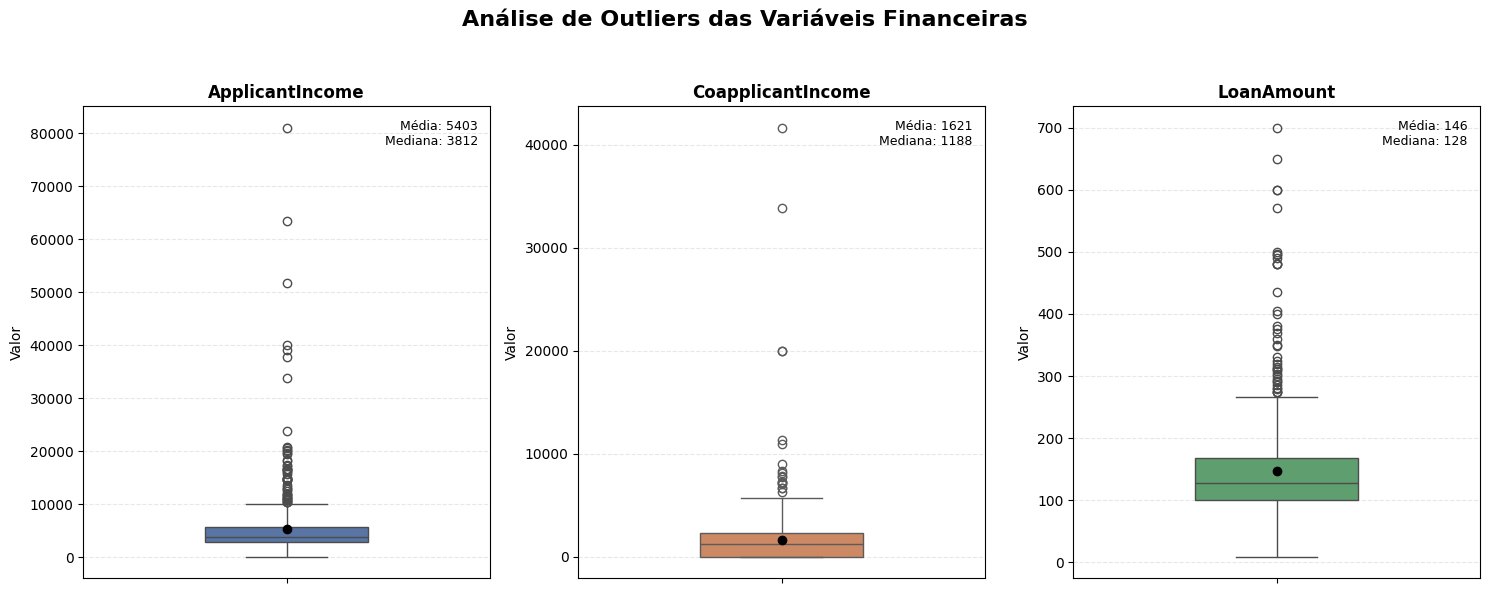

In [0]:
# --- Preparação dos dados para análise de outliers ---

import matplotlib.pyplot as plt
import seaborn as sns

colunas_outliers = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
cores = ["#4C72B0", "#DD8452", "#55A868"]

df_outliers = df_bronze.select(colunas_outliers).toPandas()

# --- Criação dos boxplots ---

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for coluna, cor, ax in zip(colunas_outliers, cores, axes):

    sns.boxplot(
        y=df_outliers[coluna],
        ax=ax,
        color=cor,
        width=0.4,
        showmeans=True,
        meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black"
    }
    )

    media = df_outliers[coluna].mean()
    mediana = df_outliers[coluna].median()

    ax.set_title(coluna, fontweight="bold")
    ax.set_ylabel("Valor")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.text(
        0.97, 0.97,
        f"Média: {media:.0f}\nMediana: {mediana:.0f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9
    )

fig.suptitle(
    "Análise de Outliers das Variáveis Financeiras",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### 3.7.2 Quantificação dos Outliers pelo IQR

A análise visual indica a presença de valores extremos nas três variáveis. Para quantificar esses registros, foram calculados os limites inferior e superior pelo método IQR. Os valores que ficam fora desses limites são considerados possíveis outliers.

In [0]:
# --- Quantificação dos outliers pelo método IQR ---

resultado_outliers = []

for coluna in colunas_outliers:
    q1, q3 = df_bronze.approxQuantile(coluna, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    qtd = df_bronze.filter(
        (F.col(coluna) < li) | (F.col(coluna) > ls)
    ).count()

    resultado_outliers.append(
        (coluna, float(q1), float(q3), float(li), float(ls), qtd)
    )

df_resultado_outliers = spark.createDataFrame(
    resultado_outliers,
    ["Atributo", "Q1", "Q3", "Limite_Inferior", "Limite_Superior", "Outliers"]
)

display(df_resultado_outliers)

Atributo,Q1,Q3,Limite_Inferior,Limite_Superior,Outliers
ApplicantIncome,2787.0,5726.0,-1621.5,10134.5,51
CoapplicantIncome,0.0,2253.0,-3379.5,5632.5,20
LoanAmount,100.0,165.0,2.5,262.5,41


### 3.7.3 Resultado da Análise de Outliers

A análise pelo método IQR confirmou a presença de possíveis outliers nas três variáveis avaliadas. Foram identificados 51 registros em `ApplicantIncome`, 20 em `CoapplicantIncome` e 41 em `LoanAmount`.

Os valores estão concentrados principalmente acima dos limites superiores calculados, o que também pode ser observado nos boxplots. Apesar de serem valores mais distantes da maior parte dos dados, isso não significa que estejam incorretos, já que rendas e valores de empréstimo podem apresentar diferenças consideráveis entre os solicitantes.

Por esse motivo, os registros não serão removidos apenas por terem sido classificados como outliers. Eles serão mantidos durante a preparação da camada Silver, evitando a exclusão de informações que podem representar situações reais.

## 3.8 Transformação dos Dados para a Camada Silver

Com a análise de qualidade concluída, nesta etapa serão realizados os tratamentos necessários para preparar os dados da camada Silver. As transformações serão feitas a partir dos problemas identificados na camada Bronze, mantendo os dados originais preservados.

Serão tratados os valores ausentes e realizados os ajustes necessários nos atributos antes da persistência dos dados tratados na camada Silver.

### 3.8.1 Tratamento dos Valores Ausentes

A análise de completude identificou valores ausentes em alguns atributos da camada Bronze. Para a construção da camada Silver, esses registros serão tratados de acordo com o tipo e o significado de cada variável, evitando a exclusão desnecessária de dados.

Para os atributos categóricos, os valores ausentes serão preenchidos pela categoria mais frequente. Já nos atributos numéricos, será utilizada a mediana, por ser menos influenciada por valores extremos.

In [0]:
# --- Criação do DataFrame que será tratado para a camada Silver ---
df_silver = df_bronze

# --- Colunas categóricas com preenchimento dos valores nulos pela moda ---
colunas_moda = ["Gender", "Married", "Dependents",
                "Self_Employed", "Credit_History"]

for coluna in colunas_moda:
    moda = (
        df_silver
        .groupBy(coluna).count()
        .filter(F.col(coluna).isNotNull())
        .orderBy(F.desc("count"))
        .first()[0]
    )

    df_silver = df_silver.fillna({coluna: moda})

# --- Colunas numéricas: preenchimento dos valores nulos pela mediana ---
colunas_mediana = ["LoanAmount", "Loan_Amount_Term"]

for coluna in colunas_mediana:
    mediana = df_silver.approxQuantile(coluna, [0.5], 0.01)[0]
    df_silver = df_silver.fillna({coluna: mediana})

# --- Validação dos valores ausentes após o tratamento ---

resultado_validacao = [
    (coluna, df_silver.filter(F.col(coluna).isNull()).count())
    for coluna in df_silver.columns
]

df_validacao = spark.createDataFrame(
    resultado_validacao,
    ["Atributo", "Valores_Nulos"]
)

display(df_validacao)

Atributo,Valores_Nulos
_c0,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0


#### 3.8.1.1 Resultado do Tratamento dos Valores Ausentes

Após o preenchimento dos valores ausentes, foi realizada uma nova verificação no conjunto de dados. Nenhum atributo apresentou valores nulos após o tratamento.

Os dados tratados permanecem no DataFrame `df_silver`, enquanto os dados originais da camada Bronze foram mantidos sem alterações.

### 3.8.2 Padronização e Ajuste dos Dados

Além do tratamento dos valores ausentes, foram avaliados outros ajustes necessários para deixar os dados mais adequados para as próximas etapas do pipeline.

Nesta etapa será removida a coluna `_c0`, que corresponde a um índice presente no arquivo de origem e não possui significado para a análise. Também serão revisados os tipos e formatos dos atributos, mantendo as informações originais sempre que não houver necessidade de alteração.

In [0]:
# --- Ajustes para a camada Silver ---

df_silver = (
    df_silver
    .drop("_c0")                                      # Remove a coluna sem significado para análise
    .withColumn("Loan_Amount_Term",
                F.col("Loan_Amount_Term").cast("int")) # Ajusta o prazo para número inteiro
    .withColumn("Credit_History",
                F.col("Credit_History").cast("int"))   # Ajusta o indicador binário para inteiro
)

# --- Verificação dos tipos após os ajustes ---
df_silver.printSchema()

root
 |-- Loan_ID: string (nullable = true)
 |-- Gender: string (nullable = false)
 |-- Married: string (nullable = false)
 |-- Dependents: string (nullable = false)
 |-- Education: string (nullable = true)
 |-- Self_Employed: string (nullable = false)
 |-- ApplicantIncome: integer (nullable = true)
 |-- CoapplicantIncome: double (nullable = true)
 |-- LoanAmount: double (nullable = false)
 |-- Loan_Amount_Term: integer (nullable = true)
 |-- Credit_History: integer (nullable = true)
 |-- Property_Area: string (nullable = true)
 |-- Loan_Status: string (nullable = true)



#### 3.8.2.1 Resultado da Padronização e Ajuste dos Dados

Após os ajustes, a coluna `_c0` foi removida por representar apenas um índice do arquivo original, sem informação relevante para a análise.

O atributo `Loan_Amount_Term` foi convertido para o tipo inteiro, pois representa o prazo do empréstimo em meses e não necessita de casas decimais. O atributo `Credit_History` também foi convertido para inteiro. Como seus valores são representados por 0 e 1, optou-se por manter essa codificação em vez de utilizar o tipo booleano, preservando o significado do atributo e facilitando sua utilização nas análises posteriores.

Os demais atributos tiveram seus tipos mantidos, pois já estavam adequados ao significado dos dados. A categoria `3+` de `Dependents` também foi preservada, já que representa três ou mais dependentes e sua conversão para o valor 3 poderia distorcer a informação original.

### 3.8.3 Validação dos Dados Tratados

Antes de persistir os dados na camada Silver, será feita uma última verificação do conjunto tratado. A intenção é confirmar se a quantidade de registros foi mantida, se os valores ausentes foram tratados e se o identificador `Loan_ID` continua sendo único após as transformações realizadas.

In [0]:
# --- Validação final dos dados tratados ---

total_registros = df_silver.count()
total_colunas = len(df_silver.columns)
loan_ids_unicos = df_silver.select("Loan_ID").distinct().count()
total_nulos = sum(
    df_silver.filter(F.col(coluna).isNull()).count()
    for coluna in df_silver.columns
)

print(f"Registros: {total_registros}")
print(f"Atributos: {total_colunas}")
print(f"Valores nulos: {total_nulos}")
print(f"Loan_ID únicos: {loan_ids_unicos}")

Registros: 614
Atributos: 13
Valores nulos: 0
Loan_ID únicos: 614


#### 3.8.3.1 Resultado da Validação dos Dados Tratados

Após os tratamentos, a base permaneceu com 614 registros e passou a ter 13 atributos, devido à remoção da coluna `_c0`. A nova verificação também confirmou que não restaram valores nulos no conjunto de dados.

Os 614 registros continuam apresentando valores únicos para `Loan_ID`, indicando que nenhuma solicitação de crédito foi perdida ou duplicada durante as transformações. Com essas verificações, os dados estão prontos para serem armazenados na camada Silver.

### 3.8.4 Persistência da Camada Silver

Com os tratamentos e as validações concluídos, o conjunto de dados será armazenado como uma nova tabela Delta no Unity Catalog. Dessa forma, a camada Bronze permanece com os dados originais, enquanto a camada Silver passa a concentrar os dados tratados e preparados para as próximas etapas do pipeline.

In [0]:
# --- Persistência dos dados tratados na camada Silver ---

(
    df_silver.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.default.loan_approval_silver")
)

print("Tabela Silver persistida com sucesso.")

Tabela Silver persistida com sucesso.


In [0]:
# --- Validação da tabela Silver persistida ---

df_silver_validacao = spark.table("workspace.default.loan_approval_silver")

print(f"Registros persistidos: {df_silver_validacao.count()}")
print(f"Atributos persistidos: {len(df_silver_validacao.columns)}")

display(df_silver_validacao.limit(10))

Registros persistidos: 614
Atributos persistidos: 13


Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001002,Male,No,0,Graduate,No,5849,0.0,126.0,360,1,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360,1,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360,1,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360,0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360,1,Urban,Y
LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360,1,Semiurban,N


#### 3.8.4.1 Resultado da Persistência

A tabela `loan_approval_silver` foi criada com sucesso no Unity Catalog em formato Delta. Após a gravação, a tabela foi carregada novamente para verificar o resultado da persistência, mantendo os 614 registros e os 13 atributos esperados.

A partir dessa tabela, os dados tratados ficam disponíveis para as próximas etapas do pipeline, sem alterar os dados originais armazenados na camada Bronze.